# CDSE OData Sentinel-2 Query, Download & ACOLITE Processing Workflow

Queries, downloads, and atmospherically corrects Sentinel-2 L1C products from the Copernicus Data Space Ecosystem (CDSE) OData API.  
Replaces the decommissioned OpenSearch/CDSETool workflow.

**API endpoint:** `https://catalogue.dataspace.copernicus.eu/odata/v1/`  
**Auth endpoint:** `https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token`

**Workflow:**
1. Query products by tile ID, date range, cloud cover (<30%), and product type (S2MSI1C)
2. Filter out N0500 reprocessed products and partial-tile scenes
3. Display numbered QUICKLOOK thumbnails for visual review
4. User selects products by index number → download list
5. Download and extract selected `.SAFE` directories
6. Run ACOLITE: Rayleigh-corrected reflectance (Rrc) with DSF residual glint correction
7. Post-process: selectively strip bands, compute cloud / land / ice masks, write output NetCDF

In [1]:
import os
import zipfile
import subprocess
import shutil
import requests
import numpy as np
import netCDF4 as nc
import yaml
from datetime import date
from math import radians, sin
from glob import glob
from tqdm import tqdm
from scipy.ndimage import binary_dilation
from IPython.display import Image, display

In [2]:
# ---------------------------------------------------------------------------
# Compute spherical area of a GeoJSON polygon (returns area in m²)
# ---------------------------------------------------------------------------
def calculate_area_long(polygon):
    coords = polygon['coordinates'][0]
    area = 0.0
    for i in range(len(coords)):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[(i + 1) % len(coords)]
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        area += (lon2 - lon1) * (2 + sin(lat1) + sin(lat2))
    area = abs(area) * 6378137.0**2 / 2.0
    return area


# ---------------------------------------------------------------------------
# List subdirectories whose names contain a target string
# ---------------------------------------------------------------------------
def list_subdirectories_with_string(srch_dir, srch_str):
    all_subdirs = [
        os.path.join(srch_dir, d)
        for d in os.listdir(srch_dir)
        if os.path.isdir(os.path.join(srch_dir, d))
    ]
    return [d for d in all_subdirs if srch_str in d]


# ---------------------------------------------------------------------------
# Extract a named attribute value from an OData product's Attributes list
# ---------------------------------------------------------------------------
def get_attribute(product, attr_name):
    for attr in product.get('Attributes', []):
        if attr['Name'] == attr_name:
            return attr['Value']
    return None

In [3]:
# ---------------------------------------------------------------------------
# Query CDSE OData catalogue for Sentinel-2 L1C products
#
# Filters applied server-side:
#   - Collection: SENTINEL-2
#   - productType: S2MSI1C  (L1C only)
#   - tileId: exact UTM tile (e.g. '22VFN')
#   - ContentDate: within [date_from, date_to]
#   - cloudCover: < cloud_cover_max  (percent, 0-100)
#
# Returns a list of product dicts with Attributes expanded.
# Handles OData pagination automatically ($top=100 per page).
# ---------------------------------------------------------------------------
def query_sentinel2_odata(tile_id, date_from, date_to, cloud_cover_max=30):
    base_url = 'https://catalogue.dataspace.copernicus.eu/odata/v1/Products'

    date_from_str = date_from.strftime('%Y-%m-%dT00:00:00.000Z')
    date_to_str   = date_to.strftime('%Y-%m-%dT23:59:59.000Z')

    filter_parts = [
        "Collection/Name eq 'SENTINEL-2'",
        "Attributes/OData.CSC.StringAttribute/any("
            "att:att/Name eq 'productType' and "
            #"att/OData.CSC.StringAttribute/Value eq 'S2MSI2A')",
            "att/OData.CSC.StringAttribute/Value eq 'S2MSI1C')",
        f"Attributes/OData.CSC.StringAttribute/any("
            f"att:att/Name eq 'tileId' and "
            f"att/OData.CSC.StringAttribute/Value eq '{tile_id}')",
        f"ContentDate/Start gt {date_from_str}",
        f"ContentDate/Start lt {date_to_str}",
        f"Attributes/OData.CSC.DoubleAttribute/any("
            f"att:att/Name eq 'cloudCover' and "
            f"att/OData.CSC.DoubleAttribute/Value lt {cloud_cover_max:.2f})",
    ]

    params = {
        '$filter':  ' and '.join(filter_parts),
        '$expand':  'Attributes',
        '$orderby': 'ContentDate/Start desc',
        '$count':   'true',
        '$top':     100,
    }

    all_products = []
    print(f'Querying tile {tile_id}  {date_from} → {date_to}  (cloud < {cloud_cover_max}%)')

    while True:
        params['$skip'] = len(all_products)
        resp = requests.get(base_url, params=params, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        page = data.get('value', [])
        all_products.extend(page)

        total = data.get('@odata.count', '?')
        print(f'  Retrieved {len(all_products)} / {total} products')

        if len(page) < 100:
            break

    return all_products

In [4]:
# ---------------------------------------------------------------------------
# Obtain an OAuth2 access token from the CDSE identity service
# ---------------------------------------------------------------------------
def get_access_token(username, password):
    token_url = (
        'https://identity.dataspace.copernicus.eu'
        '/auth/realms/CDSE/protocol/openid-connect/token'
    )
    payload = {
        'client_id':  'cdse-public',
        'grant_type': 'password',
        'username':   username,
        'password':   password,
    }
    resp = requests.post(token_url, data=payload, timeout=30)
    resp.raise_for_status()
    token = resp.json()['access_token']
    print('Access token obtained.')
    return token


# ---------------------------------------------------------------------------
# Download a product by its OData ID, with a progress bar.
# The .zip is extracted in-place and the archive is deleted.
# ---------------------------------------------------------------------------
def download_product(product_id, product_name, download_path, access_token):
    base_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    url = f"{base_url}({product_id})/$value"

    headers = {"Authorization": f"Bearer {access_token}"}

    os.makedirs(download_path, exist_ok=True)
    zip_path = os.path.join(download_path, f"{product_name}.zip")

    with requests.Session() as session:
        session.headers.update(headers)

        # STEP 1: get redirect URL (no auto redirect)
        resp = session.get(url, allow_redirects=False)
        resp.raise_for_status()

        if resp.status_code in (301, 302, 303, 307):
            download_url = resp.headers["Location"]
        else:
            download_url = url

        # STEP 2: download with auth header explicitly
        with session.get(download_url, stream=True, timeout=600) as r:
            r.raise_for_status()

            total = int(r.headers.get("content-length", 0))
            with open(zip_path, "wb") as fh, tqdm(
                total=total, unit="B", unit_scale=True, desc=product_name
            ) as pbar:
                for chunk in r.iter_content(chunk_size=65536):
                    if chunk:
                        fh.write(chunk)
                        pbar.update(len(chunk))

    print(f"Extracting {product_name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_path)

    os.remove(zip_path)
    print(f"Done → {download_path}\n")


In [5]:
# ---------------------------------------------------------------------------
# Display the QUICKLOOK thumbnail for a product.
# The optional index argument prints the [N] label alongside the URL so
# thumbnails can be cross-referenced with the numbered product list.
# ---------------------------------------------------------------------------
def show_thumbnail(product_id, product_name, index=None):
    url = f'https://catalogue.dataspace.copernicus.eu/odata/v1/Products({product_id})'
    try:
        resp = requests.get(url, params={'$expand': 'Assets'}, timeout=30)
        resp.raise_for_status()
        assets = resp.json().get('Assets', [])
        ql = next((a for a in assets if a.get('Type') == 'QUICKLOOK'), None)
        if not ql:
            print('  (no QUICKLOOK asset found)')
            return
        tn_url = (
            f"https://catalogue.dataspace.copernicus.eu"
            f"/odata/v1/Assets({ql['Id']})/$value"
        )
        img_data = requests.get(tn_url, timeout=30).content
        label = f'[{index}] ' if index is not None else ''
        print(f'  {label}Thumbnail: {tn_url}')
        display(Image(data=img_data, width=400))
    except Exception as e:
        print(f'  (thumbnail unavailable: {e})')

In [6]:
# ---------------------------------------------------------------------------
# ACOLITE output directory locator
# ACOLITE (Python dist) creates a subdirectory named after the input product
# (without the .SAFE extension) under the configured output root.
# ---------------------------------------------------------------------------
def acolite_output_dir(acolite_out, l1c):
    basename   = os.path.basename(os.path.normpath(l1c))
    product_id = basename.replace('.SAFE', '')
    return os.path.join(acolite_out, product_id)


def find_l2r_files(acolite_out, l1c):
    '''
    Locate _L2R.nc files produced by ACOLITE for a given L1C scene.
    Tries the expected subdirectory first; falls back to a date+tile glob.
    '''
    expected_dir = acolite_output_dir(acolite_out, l1c)
    l2r = sorted(glob(os.path.join(expected_dir, '*_L2R.nc')))
    if l2r:
        return l2r
    # Fallback: search entire output tree using acquisition date and tile ID
    basename = os.path.basename(os.path.normpath(l1c))
    parts    = basename.split('_')
    if len(parts) >= 6:
        acq_dt    = parts[2][:8]    # e.g. '20240515'
        tile_part = parts[5]        # e.g. 'T22VFN'
        pattern   = os.path.join(acolite_out, '**',
                                 f'*{acq_dt}*{tile_part}*_L2R.nc')
        l2r = sorted(glob(pattern, recursive=True))
    return l2r


# ---------------------------------------------------------------------------
# Band exclusion list builder
# ---------------------------------------------------------------------------
def get_bands_to_exclude(nc_path, exclude_rhot=True, exclude_rhos=True,
                         exclude_rrc_edges=True):
    '''
    Return a list of NetCDF variable names to omit from the output file.

    exclude_rhot       : strip all rhot_* (TOA reflectance bands)
    exclude_rhos       : strip all rhos_* (DSF surface reflectance bands)
    exclude_rrc_edges  : strip rhorc_* at near-UV / red-edge wavelengths:
                           S2A: 443, 704, 740, 783, 865 nm
                           S2B: 442, 704, 739, 780, 864 nm
    '''
    S2A_edge = {443, 704, 740, 783, 865}
    S2B_edge = {442, 704, 739, 780, 864}

    basename = os.path.basename(nc_path)
    edge_wl  = S2A_edge if 'S2A' in basename else S2B_edge

    to_exclude = []
    with nc.Dataset(nc_path) as ds:
        for varname in ds.variables:
            if exclude_rhot and varname.startswith('rhot_'):
                to_exclude.append(varname)
            elif exclude_rhos and varname.startswith('rhos_'):
                to_exclude.append(varname)
            elif exclude_rrc_edges and varname.startswith('rhorc_'):
                try:
                    wl = int(varname.split('_')[1])
                    if wl in edge_wl:
                        to_exclude.append(varname)
                except (IndexError, ValueError):
                    pass
    return to_exclude

In [7]:
# ---------------------------------------------------------------------------
# Mask configuration loader
# ---------------------------------------------------------------------------
def load_mask_config(config_path):
    '''Load mask threshold parameters from a YAML file.'''
    with open(config_path) as f:
        return yaml.safe_load(f)


# ---------------------------------------------------------------------------
# Band reader
# ---------------------------------------------------------------------------
def _read_band(nc_path, band_name):
    '''
    Read a single variable from a NetCDF file as a float32 ndarray.
    Fills masked / fill values with NaN.  Returns None if the band is absent.
    '''
    with nc.Dataset(nc_path) as ds:
        if band_name not in ds.variables:
            return None
        data = ds.variables[band_name][:]
    if hasattr(data, 'filled'):
        return data.filled(np.nan).astype(np.float32)
    return np.asarray(data, dtype=np.float32)


def _threshold_band(nc_path, primary, fallback, threshold, label):
    '''
    Load a band (primary; fallback if absent) and threshold it.
    Returns a bool ndarray (True = pixel is masked), or None if unavailable.
    NaN / fill pixels compare False and are therefore not masked here.
    '''
    data = _read_band(nc_path, primary)
    if data is None:
        print(f'  WARNING [{label}]: {primary} not found — trying {fallback}')
        data = _read_band(nc_path, fallback) if fallback else None
    if data is None:
        print(f'  WARNING [{label}]: no suitable band found — mask skipped.')
        return None
    return data > threshold


# ---------------------------------------------------------------------------
# Individual mask functions
# ---------------------------------------------------------------------------
def compute_cloud_mask(nc_path, cfg):
    '''Cloud mask: TOA reflectance > threshold at 1375 nm (cirrus band).'''
    return _threshold_band(
        nc_path,
        primary   = cfg['cloud']['band'],
        fallback  = cfg['cloud'].get('fallback_band'),
        threshold = cfg['cloud']['threshold'],
        label     = 'cloud',
    )


def compute_land_mask(nc_path, cfg):
    '''Land mask: SWIR L2R reflectance > threshold.'''
    return _threshold_band(
        nc_path,
        primary   = cfg['land']['band'],
        fallback  = cfg['land'].get('fallback_band'),
        threshold = cfg['land']['threshold'],
        label     = 'land',
    )


def compute_ice_bright_mask(nc_path, cfg):
    '''Ice / bright-pixel mask: red-band reflectance > threshold.'''
    return _threshold_band(
        nc_path,
        primary   = cfg['ice_bright']['band'],
        fallback  = cfg['ice_bright'].get('fallback_band'),
        threshold = cfg['ice_bright']['threshold'],
        label     = 'ice/bright',
    )


# ---------------------------------------------------------------------------
# Combine and dilate
# ---------------------------------------------------------------------------
def _resize_to(arr, target_shape):
    '''Nearest-neighbour resize of a bool array to target_shape (scipy zoom).'''
    if arr.shape == target_shape:
        return arr
    from scipy.ndimage import zoom as ndzoom
    zy = target_shape[0] / arr.shape[0]
    zx = target_shape[1] / arr.shape[1]
    return ndzoom(arr.astype(np.float32), (zy, zx), order=0) > 0.5


def combine_and_dilate(cloud, land, ice_bright, dil_cfg):
    '''
    OR-combine individual masks, then optionally dilate the boundary by N
    pixels using a square structuring element (side = 2N+1 pixels).
    Returns a bool ndarray, or None if all inputs are None.
    '''
    arrays = [m for m in (cloud, land, ice_bright) if m is not None]
    if not arrays:
        return None

    ref_shape = max(arrays, key=lambda a: a.size).shape
    combined  = np.zeros(ref_shape, dtype=bool)
    for arr in arrays:
        combined |= _resize_to(arr, ref_shape)

    if dil_cfg.get('apply', False):
        n      = int(dil_cfg.get('pixels', 3))
        struct = np.ones((2 * n + 1, 2 * n + 1), dtype=bool)
        combined = binary_dilation(combined, structure=struct)

    return combined


def compute_masks(nc_path, mask_cfg):
    '''Compute all masks for one L2R scene.  Returns a dict of bool arrays.'''
    cloud      = compute_cloud_mask(nc_path, mask_cfg)
    land       = compute_land_mask(nc_path, mask_cfg)
    ice_bright = compute_ice_bright_mask(nc_path, mask_cfg)
    combined   = combine_and_dilate(
        cloud, land, ice_bright, mask_cfg.get('dilation', {})
    )
    return {
        'mask_cloud':      cloud,
        'mask_land':       land,
        'mask_ice_bright': ice_bright,
        'mask_combined':   combined,
    }

In [8]:
# ---------------------------------------------------------------------------
# NetCDF copy with band filtering and optional mask embedding
# ---------------------------------------------------------------------------

def _write_mask_vars(dst_ds, masks):
    '''Write mask arrays as int8 variables into an open writable nc.Dataset.'''
    for name, arr in masks.items():
        if arr is None:
            continue
        v = dst_ds.createVariable(name, 'i1', ('y', 'x'))
        v[:] = arr.astype(np.int8)
        v.long_name     = name.replace('_', ' ')
        v.flag_values   = np.array([0, 1], dtype=np.int8)
        v.flag_meanings = 'valid masked'


def nc_copy_filtered(l2rnc, to_exclude, masks=None,
                     save_masks_in_rrc=True, save_masks_separate=False):
    '''
    Copy the L2R NetCDF to <base>_RRC.nc, omitting variables in to_exclude.

    save_masks_in_rrc    : embed mask variables in the _RRC.nc output
    save_masks_separate  : also write a companion _mask.nc file

    Returns the path of the _RRC.nc file written.
    '''
    rrc_path = l2rnc[:-3] + '_RRC.nc'      # …_L2R.nc  →  …_L2R_RRC.nc

    with nc.Dataset(l2rnc) as src, nc.Dataset(rrc_path, 'w') as dst:
        dst.setncatts(src.__dict__)
        for name, dim in src.dimensions.items():
            dst.createDimension(name, None if dim.isunlimited() else len(dim))
        for name, var in src.variables.items():
            if name in to_exclude:
                continue
            v = dst.createVariable(name, var.datatype, var.dimensions)
            v[:] = src[name][:]
            v.setncatts(src[name].__dict__)
        if save_masks_in_rrc and masks:
            _write_mask_vars(dst, masks)
    print(f'  Written: {os.path.basename(rrc_path)}')

    if save_masks_separate and masks:
        mask_path = l2rnc[:-3] + '_mask.nc'
        coord_vars = {'x', 'y', 'lon', 'lat', 'transverse_mercator'}
        with nc.Dataset(l2rnc) as src, nc.Dataset(mask_path, 'w') as dst:
            dst.setncatts(src.__dict__)
            for name, dim in src.dimensions.items():
                dst.createDimension(name, None if dim.isunlimited() else len(dim))
            for coord in coord_vars:
                if coord in src.variables:
                    v  = src.variables[coord]
                    dv = dst.createVariable(coord, v.datatype, v.dimensions)
                    dv[:] = src[coord][:]
                    dv.setncatts(src[coord].__dict__)
            _write_mask_vars(dst, masks)
        print(f'  Written: {os.path.basename(mask_path)}')

    return rrc_path

In [9]:
# ---------------------------------------------------------------------------
# RRC analysis helpers — RGB GeoTIFF, median filter, NDVI, FAI
# (REQ-RRC-001 through REQ-RRC-007)
# ---------------------------------------------------------------------------
import rasterio
import rasterio.transform
from scipy.ndimage import median_filter as _median_filter


def _build_geotiff_profile(rrc_path):
    '''Build a rasterio profile dict (CRS + affine transform) from an RRC NetCDF.
    CRS is read directly from the transverse_mercator.crs_wkt attribute;
    no EPSG codes are hardcoded (REQ-RRC-006).
    '''
    with nc.Dataset(rrc_path) as ds:
        x = np.asarray(ds.variables['x'][:], dtype=float)
        y = np.asarray(ds.variables['y'][:], dtype=float)
        crs_wkt = ds.variables['transverse_mercator'].crs_wkt
    dx = x[1] - x[0]
    dy = y[1] - y[0]          # negative (north-to-south storage)
    transform = rasterio.transform.from_origin(
        west  = x[0] - dx / 2,
        north = y[0] - dy / 2,  # dy < 0, so north = y[0] + |dy|/2
        xsize = abs(dx),
        ysize = abs(dy),
    )
    return {
        'driver'   : 'GTiff',
        'dtype'    : 'float32',
        'crs'      : crs_wkt,
        'transform': transform,
        'width'    : len(x),
        'height'   : len(y),
        'nodata'   : float('nan'),
    }


def write_rgb_geotiff(rrc_path, out_path,
                      red='rhorc_665', green='rhorc_560', blue='rhorc_492'):
    '''Write an unmasked 3-band float32 GeoTIFF from an RRC NetCDF.
    Bands: red=rhorc_665, green=rhorc_560, blue=rhorc_492 (REQ-RRC-001).
    No mask is applied — the RGB is intentionally unmasked (SCENARIO-RRC-001).
    '''
    profile = _build_geotiff_profile(rrc_path)
    profile['count'] = 3
    bands = []
    with nc.Dataset(rrc_path) as ds:
        for name in (red, green, blue):
            arr = ds.variables[name][:]
            if hasattr(arr, 'filled'):
                arr = arr.filled(np.nan)
            bands.append(arr.astype(np.float32))
    with rasterio.open(out_path, 'w', **profile) as dst:
        for i, arr in enumerate(bands, start=1):
            dst.write(arr, i)
    print(f'  Written: {os.path.basename(out_path)}')


def compute_indices(rrc_path, filter_size=7):
    '''Apply a median filter to rhorc bands, then compute NDVI and FAI.

    NDVI = (rhorc_833 - rhorc_665) / (rhorc_833 + rhorc_665)
           NaN where either band <= 0 (REQ-RRC-003, SCENARIO-RRC-003).

    FAI (Floating Algae Index, Hu 2009):
           rhorc_833 - baseline
           baseline = rhorc_665 + (rhorc_1614 - rhorc_665)
                          * (833 - 665) / (1614 - 665)
           Negative over clear water (SCENARIO-RRC-004).

    The 7x7 median filter (REQ-RRC-002) suppresses whitecap speckle and
    glint residuals before index arithmetic.

    Returns dict with keys: ndvi, fai, mask_combined.
    '''
    with nc.Dataset(rrc_path) as ds:
        def _load(name):
            arr = ds.variables[name][:]
            return (arr.filled(np.nan).astype(np.float32)
                    if hasattr(arr, 'filled')
                    else np.asarray(arr, dtype=np.float32))

        red  = _load('rhorc_665')
        nir  = _load('rhorc_833')
        swir = _load('rhorc_1614')
        mask = (_load('mask_combined').astype(bool)
                if 'mask_combined' in ds.variables else None)

    # 7x7 median filter on each band (REQ-RRC-002)
    red  = _median_filter(red,  size=filter_size).astype(np.float32)
    nir  = _median_filter(nir,  size=filter_size).astype(np.float32)
    swir = _median_filter(swir, size=filter_size).astype(np.float32)

    # NDVI (REQ-RRC-003)
    with np.errstate(invalid='ignore', divide='ignore'):
        ndvi = np.where(
            (red > 0) & (nir > 0),
            (nir - red) / (nir + red),
            np.nan,
        ).astype(np.float32)

    # FAI — baseline interpolation between red and SWIR (REQ-RRC-004)
    wl_red, wl_nir, wl_swir = 665.0, 833.0, 1614.0
    baseline = red + (swir - red) * (wl_nir - wl_red) / (wl_swir - wl_red)
    fai = (nir - baseline).astype(np.float32)

    return {'ndvi': ndvi, 'fai': fai, 'mask_combined': mask}


def write_index_geotiff(index_arr, mask_combined, rrc_path, out_path):
    '''Write a masked single-band index (NDVI or FAI) as a float32 GeoTIFF.
    Pixels where mask_combined is True are set to NaN (REQ-RRC-005, SCENARIO-RRC-005).
    '''
    arr = index_arr.copy()
    if mask_combined is not None:
        arr[mask_combined] = np.nan
    profile = _build_geotiff_profile(rrc_path)
    profile['count'] = 1
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(arr, 1)
    print(f'  Written: {os.path.basename(out_path)}')


---
## Configuration

Edit the cells in this section before running the workflow.

In [18]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# --- paths ---
download_path = '/path/to/s2_download/'

# --- CDSE credentials ---
username = 'your_cdse_email@example.com'
password = 'your_cdse_password'

# --- query parameters ---
tile_id   = '23VLH'   # UTM tile ID
cloud_max = 70        # maximum cloud cover (%)
tile_pct  = 0.5       # minimum fraction of full tile required
show_tn   = True      # display QUICKLOOK thumbnails during query

y = 2025
m = 9
date_list = [[1, 31]]   # list of [day_start, day_end] windows within the month

use_filters = False

# Reference area of a full 110 km x 110 km Sentinel-2 tile (m^2)
full_tile_area = (110 * 1000) ** 2

---
## Step 1 — Query & Thumbnail Review

Run this cell to query CDSE and display numbered thumbnails.  
Each product that passes the cloud-cover and tile-area filters is assigned
an index `[N]`.  Note the indices of products you want to download.

Querying tile 23VLH  2025-09-01 → 2025-09-30  (cloud < 70%)
  Retrieved 9 / 9 products
[0]  S2A_MSIL1C_20250922T144241_N0511_R039_T23VLH_20250922T181531.SAFE
       Cloud cover   : 21.6%
       Tile coverage : 99.3%
       Acquisition   : 2025-09-22
  [0] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(f03b4371-bc10-4478-91d0-8b969e3477d4)/$value


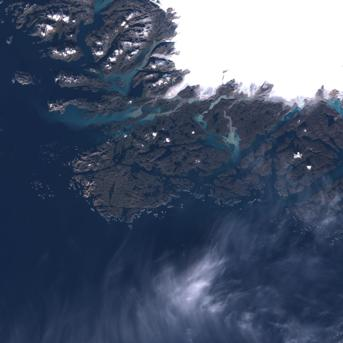


[1]  S2B_MSIL1C_20250922T142819_N0511_R139_T23VLH_20250922T180348.SAFE
       Cloud cover   : 25.1%
       Tile coverage : 95.4%
       Acquisition   : 2025-09-22
  [1] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(df62c660-b261-461a-9640-b42554417eb2)/$value


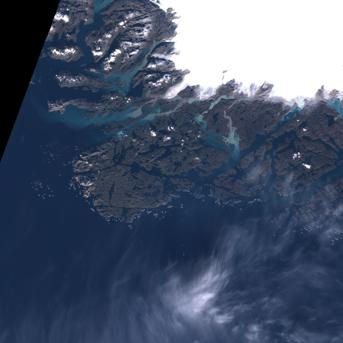


[2]  S2C_MSIL1C_20250913T144831_N0511_R082_T23VLH_20250913T195805.SAFE
       Cloud cover   : 21.3%
       Tile coverage : 34.8%
       Acquisition   : 2025-09-13
  [2] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(8aa5b433-6489-4729-9d8d-29384b9eb607)/$value


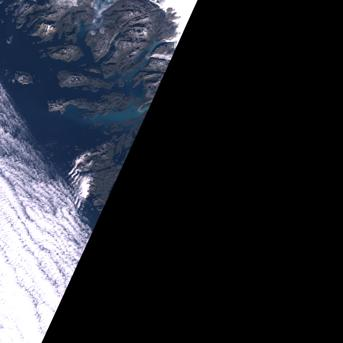


[3]  S2A_MSIL1C_20250912T143821_N0511_R039_T23VLH_20250912T181458.SAFE
       Cloud cover   : 12.6%
       Tile coverage : 99.3%
       Acquisition   : 2025-09-12
  [3] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(62d3e0c9-ca15-482f-89a2-472404a6678a)/$value


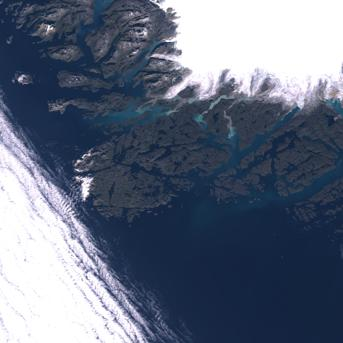


[4]  S2B_MSIL1C_20250912T142739_N0511_R139_T23VLH_20250912T180333.SAFE
       Cloud cover   : 13.0%
       Tile coverage : 95.6%
       Acquisition   : 2025-09-12
  [4] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(8696ce8b-08a0-4a04-b252-b3ce80372b27)/$value


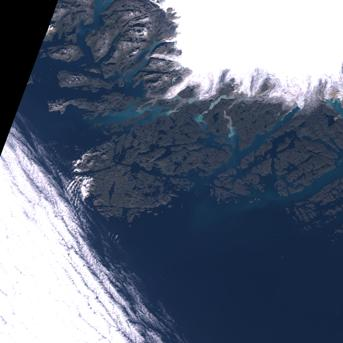


[5]  S2C_MSIL1C_20250910T143811_N0511_R039_T23VLH_20250910T181819.SAFE
       Cloud cover   : 9.6%
       Tile coverage : 99.3%
       Acquisition   : 2025-09-10
  [5] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(e630e042-dc19-47f1-a4f8-55cade18fc44)/$value


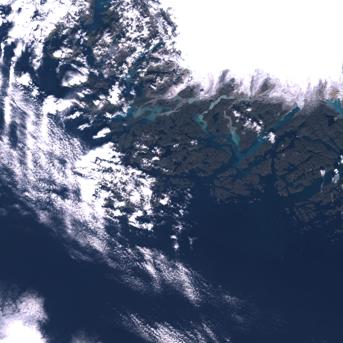


[6]  S2A_MSIL1C_20250905T144801_N0511_R082_T23VLH_20250905T182737.SAFE
       Cloud cover   : 23.2%
       Tile coverage : 35.2%
       Acquisition   : 2025-09-05
  [6] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(0dea63f6-b19b-4bef-80bb-8b9bec5f287e)/$value


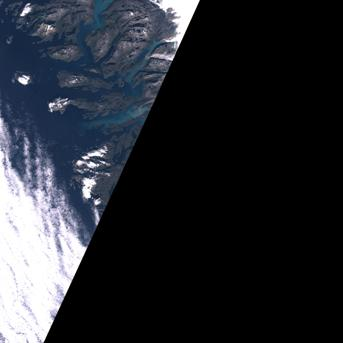


[7]  S2B_MSIL1C_20250905T143749_N0511_R039_T23VLH_20250905T181332.SAFE
       Cloud cover   : 11.5%
       Tile coverage : 99.3%
       Acquisition   : 2025-09-05
  [7] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(e260b943-d0a0-4103-8a5a-7003cfea5bfd)/$value


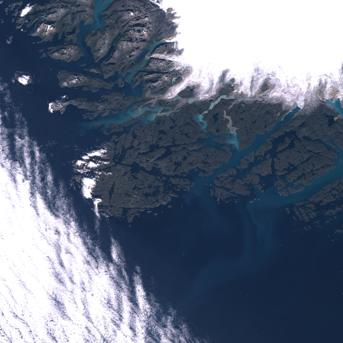


[8]  S2C_MSIL1C_20250903T145011_N0511_R082_T23VLH_20250903T182813.SAFE
       Cloud cover   : 7.4%
       Tile coverage : 34.5%
       Acquisition   : 2025-09-03
  [8] Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(4da2990f-2347-4e6c-b078-8135d3cae416)/$value


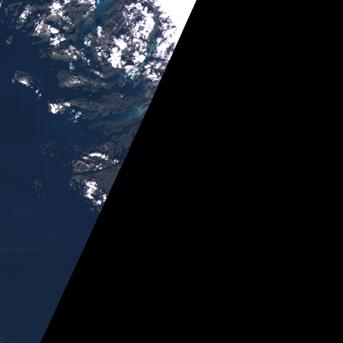



9 product(s) passed filters.
Set selected_indices in the next cell to choose products for download.


In [19]:
# ---------------------------------------------------------------------------
# Query CDSE and display numbered thumbnails.
# Products that pass all filters are stored in display_products.
# ---------------------------------------------------------------------------

display_products = []   # products shown to the user, in display order

for dent in date_list:
    date_from = date(y, m, dent[0])
    try:
        date_to = date(y, m, dent[1])
    except ValueError:
        date_to = date(y, m, dent[1] - 1)

    products = query_sentinel2_odata(
        tile_id, date_from, date_to, cloud_cover_max=cloud_max
    )

    if not products:
        print('  No products found for this date window.')
        continue

    for product in products:
        name = product['Name']
        pid  = product['Id']
        cc   = get_attribute(product, 'cloudCover') or 0.0
        fgeo = product.get('GeoFootprint')
        
        if fgeo is None:
            print(f'  {name}: no footprint geometry, skipping.')
            continue
        
        tile_area = calculate_area_long(fgeo)
        coverage  = tile_area / full_tile_area
        #if coverage < tile_pct:
        #    continue

        idx = len(display_products)
        display_products.append(product)

        acq_date = product['ContentDate']['Start'][:10]
        print(f'[{idx}]  {name}')
        print(f'       Cloud cover   : {float(cc):.1f}%')
        print(f'       Tile coverage : {coverage * 100:.1f}%')
        print(f'       Acquisition   : {acq_date}')

        if show_tn:
            show_thumbnail(pid, name, index=idx)
        print()

print(f'\n{len(display_products)} product(s) passed filters.')
print('Set selected_indices in the next cell to choose products for download.')

---
## Step 2 — Build Download List

Edit `selected_indices` below and run the cell to confirm your selection.

In [20]:
# ---------------------------------------------------------------------------
# Set selected_indices to the [N] labels shown above, then run this cell.
#
# Examples:
#   selected_indices = [0, 2, 5]                           # specific products
#   selected_indices = list(range(len(display_products)))  # all products
#   selected_indices = []                                   # skip download
# ---------------------------------------------------------------------------

selected_indices = [7]   # <-- edit this list

download_list = [display_products[i] for i in selected_indices]
print(f'{len(download_list)} product(s) selected:')
for p in download_list:
    print(f"  {p['Name']}")

1 product(s) selected:
  S2B_MSIL1C_20250905T143749_N0511_R039_T23VLH_20250905T181332.SAFE


In [21]:
# ---------------------------------------------------------------------------
# Download selected products
# ---------------------------------------------------------------------------

if not download_list:
    print('No products selected.  Edit selected_indices and re-run Step 2.')
else:
    access_token = get_access_token(username, password)
    for product in download_list:
        pid      = product['Id']
        name     = product['Name']
        safe_dir = os.path.join(download_path, name)
        if os.path.isdir(safe_dir):
            print(f'  Already present, skipping: {name}')
            continue
        download_product(pid, name, download_path, access_token)

Access token obtained.


S2B_MSIL1C_20250905T143749_N0511_R039_T23VLH_20250905T181332.SAFE: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 738M/738M [01:56<00:00, 6.32MB/s]


---
## Step 3 — ACOLITE Atmospheric Correction

Processes downloaded L1C `.SAFE` directories to produce Rayleigh-corrected
reflectance (`rhorc`) with DSF residual sunglint correction.

**Post-processing (runs automatically after each scene):**
1. Build a band exclusion list from the toggles in the config cell below
2. Compute cloud, land, and ice/bright pixel masks from the L2R output
3. Combine masks (logical OR) and optionally dilate boundaries by N pixels
4. Write filtered output as `..._L2R_RRC.nc`; optionally write `..._mask.nc`
5. Delete the original `..._L2R.nc` to free disk space

Mask thresholds are read from `mask_config.yml`.  Edit that file to tune
sensitivity without modifying this notebook.

In [26]:
# ---------------------------------------------------------------------------
# ACOLITE configuration
# ---------------------------------------------------------------------------

acolite_dir  = '/path/to/acolite/'
acolite_out  = '/path/to/acolite_output/'
settings_fnm = os.path.join(acolite_dir, 'greenfloat_settings.txt')

# --- NASA Earthdata credentials (needed by ACOLITE for ancillary data) ---
earthdata_user = 'your_cdse_email@example.com'
earthdata_pass = 'dlfhXh1ns9Q3'

# --- Band exclusion toggles (each is independently configurable) ---
exclude_rhot      = True   # strip all rhot_* (TOA reflectance bands)
exclude_rhos      = True   # strip all rhos_* (DSF surface reflectance bands)
exclude_rrc_edges = True   # strip rhorc_* at near-UV / red-edge wavelengths:
                           #   S2A: 443, 704, 740, 783, 865 nm
                           #   S2B: 442, 704, 739, 780, 864 nm

# --- Mask output options ---
mask_config_path    = '/path/to/mask_config.yml'  # path to mask threshold YAML
save_masks_in_rrc   = True               # embed mask vars in _RRC.nc
save_masks_separate = False              # also write a companion _mask.nc

# --- ACOLITE run settings ---
set_str = [
    f'EARTHDATA_u={earthdata_user}',
    f'EARTHDATA_p={earthdata_pass}',
    f'output={acolite_out}',
    's2_target_res=10',
    'output_rhorc=True',
    'dsf_residual_glint_correction=True',
    'dsf_residual_glint_correction_method=default',
    'l1r_delete_netcdf=True',
]

In [27]:
# ---------------------------------------------------------------------------
# Run ACOLITE and post-process each scene
# ---------------------------------------------------------------------------

mask_cfg = load_mask_config(mask_config_path)

l1c_dirs = list_subdirectories_with_string(download_path, 'S2A_MSIL1C_20170710T145911_N0500_R125_T22WDS_20230901T062816.SAFE')
print(f'Found {len(l1c_dirs)} .SAFE directories.')

os.chdir(acolite_dir)

for l1c in sorted(l1c_dirs):
    basename = os.path.basename(os.path.normpath(l1c))
    print(f'\n--- {basename} ---')

    # --- write ACOLITE settings file ---
    with open(settings_fnm, 'w') as fh:
        fh.write(f'inputfile={l1c}\n')
        for s in set_str:
            fh.write(s + '\n')

    # --- run ACOLITE ---
    subprocess.run(
        'python launch_acolite.py --cli --settings=greenfloat_settings.txt',
        shell=True, check=True
    )

print('\nAtmospheric Correction Complete.')

Found 1 .SAFE directories.

--- S2A_MSIL1C_20170710T145911_N0500_R125_T22WDS_20230901T062816.SAFE ---


In [20]:
# --- locate L2R NetCDF output ---
l2r_files = find_l2r_files(acolite_out, l1c)
srch_str = f"{acolite_out}*_L2R.nc"
l2r_files = sorted(glob(srch_str))

if not l2r_files:
    print('  WARNING: no _L2R.nc found — check acolite_out path.')

for l2rnc in l2r_files:
    print(f'  Post-processing: {os.path.basename(l2rnc)}')

    to_exclude = get_bands_to_exclude(
        l2rnc,
        exclude_rhot      = exclude_rhot,
        exclude_rhos      = exclude_rhos,
        exclude_rrc_edges = exclude_rrc_edges,
    )

    masks = compute_masks(l2rnc, mask_cfg)

    nc_copy_filtered(
        l2rnc, to_exclude, masks = masks,
        save_masks_in_rrc   = save_masks_in_rrc,
        save_masks_separate = save_masks_separate,
    )

    os.remove(l2rnc)
    print(f'  Removed: {os.path.basename(l2rnc)}')

  Post-processing: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R.nc
  WARNING [cloud]: rhot_1375 not found — trying rhot_1614
  Written: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R_RRC.nc
  Removed: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R.nc
  Post-processing: S2B_MSI_2017_07_11_15_24_46_T21WXM_L2R.nc
  WARNING [cloud]: rhot_1375 not found — trying rhot_1614
  WARNING [cloud]: no suitable band found — mask skipped.
  WARNING [land]: rhorc_1614 not found — trying rhorc_2202
  WARNING [land]: no suitable band found — mask skipped.
  Written: S2B_MSI_2017_07_11_15_24_46_T21WXM_L2R_RRC.nc
  Removed: S2B_MSI_2017_07_11_15_24_46_T21WXM_L2R.nc


---
## Step 4 — RRC Analysis: Spectral Indices and GeoTIFF Export

Reads an existing `_RRC.nc` file and produces:
1. **Unmasked RGB GeoTIFF** — `rhorc_665` / `rhorc_560` / `rhorc_492`
2. **Masked NDVI GeoTIFF** — 7×7 median-filtered bands; `mask_combined` applied
3. **Masked FAI GeoTIFF** — Floating Algae Index (NIR minus red–SWIR baseline); `mask_combined` applied

Edit `rrc_path` and `analysis_out` in the config cell, then run the execution cell.


In [21]:
# ---------------------------------------------------------------------------
# Step 4 configuration — edit before running
# ---------------------------------------------------------------------------

# Path to an existing _RRC.nc file
rrc_path = (
    '/home/user/Documents/Data/Sentinel2/acolite_output/'
    'S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R_RRC.nc'
)

# Directory for GeoTIFF outputs (defaults to same directory as rrc_path)
analysis_out = os.path.dirname(rrc_path)


In [22]:
# ---------------------------------------------------------------------------
# Run RRC analysis — writes RGB, NDVI, and FAI GeoTIFFs (REQ-RRC-007)
# ---------------------------------------------------------------------------

base = os.path.basename(rrc_path).replace('_RRC.nc', '')
rgb_path  = os.path.join(analysis_out, base + '_RGB.tif')
ndvi_path = os.path.join(analysis_out, base + '_NDVI.tif')
fai_path  = os.path.join(analysis_out, base + '_FAI.tif')

# 1. Unmasked RGB (REQ-RRC-001)
write_rgb_geotiff(rrc_path, rgb_path)

# 2 & 3. Median-filtered NDVI + FAI with mask applied (REQ-RRC-002 through REQ-RRC-005)
indices = compute_indices(rrc_path, filter_size=7)
write_index_geotiff(indices['ndvi'], indices['mask_combined'], rrc_path, ndvi_path)
write_index_geotiff(indices['fai'],  indices['mask_combined'], rrc_path, fai_path)

print('\nAnalysis complete.')


  Written: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R_RGB.tif
  Written: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R_NDVI.tif
  Written: S2A_MSI_2017_07_10_15_04_47_T22WDS_L2R_FAI.tif

Analysis complete.


---
## Optional: zip processed L1C directories and clean up

In [ ]:
# ---------------------------------------------------------------------------
# Re-zip each .SAFE directory into the 'processed' sub-folder, then delete.
# Uncomment to run.
# ---------------------------------------------------------------------------

processed_dir = os.path.join(download_path, 'processed')
os.makedirs(processed_dir, exist_ok=True)

l1c_dirs = list_subdirectories_with_string(download_path, '.SAFE')

# for l1c in l1c_dirs:
#     base = os.path.basename(os.path.normpath(l1c)).split('.')[0]
#     zip_out = os.path.join(processed_dir, base)
#     print(f'Zipping {base} ...')
#     shutil.make_archive(zip_out, 'zip', l1c)
#     shutil.rmtree(l1c)
#     print(f'  Saved to {zip_out}.zip')

In [ ]:
# OLD
'''
def download_product(product_id, product_name, download_path, access_token):
    url = (
        f'https://catalogue.dataspace.copernicus.eu'
        f'/odata/v1/Products({product_id})/$value'
    )
    headers = {'Authorization': f'Bearer {access_token}'}
    os.makedirs(download_path, exist_ok=True)
    zip_path = os.path.join(download_path, f'{product_name}.zip')

    with requests.Session() as session:
        session.headers.update(headers)
        resp = session.get(url, stream=True, allow_redirects=True, timeout=600)
        resp.raise_for_status()

        total = int(resp.headers.get('content-length', 0))
        with open(zip_path, 'wb') as fh, tqdm(
            total=total, unit='B', unit_scale=True, desc=product_name
        ) as pbar:
            for chunk in resp.iter_content(chunk_size=65536):
                fh.write(chunk)
                pbar.update(len(chunk))

    print(f'Extracting {product_name} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(download_path)
    os.remove(zip_path)
    print(f'Done → {download_path}\n')
'''